In [9]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load the dataset (adjust path if needed)
df = pd.read_csv('../data/energy_features.csv', parse_dates=['timestamp'])

# Confirm it loaded correctly
print(df.shape)
df.head()


df = df.set_index('timestamp')
values = df[['demand', 'temp', 'humidity', 'wind_speed']].values

scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)


(8784, 10)


In [10]:
df.head()



,solar_gen,wind_gen,demand,temp,humidity,wind_speed,hour,dayofweek,is_weekend
timestamp,,,,,,,,,
2024-01-01 00:00:00,0.0,402.84,9674.05,22.23,72.5,4.16,0,0,0
2024-01-01 01:00:00,0.0,535.44,9807.37,20.74,79.2,3.77,1,0,0
2024-01-01 02:00:00,0.0,1068.08,10010.68,20.91,81.6,6.47,2,0,0
2024-01-01 03:00:00,0.0,392.57,9745.17,21.18,78.4,4.14,3,0,0
2024-01-01 04:00:00,0.0,375.33,9914.20,18.35,82.5,4.15,4,0,0


In [11]:
X, y = [], []
for i in range(24, len(scaled)):
    X.append(scaled[i-24:i])
    y.append(scaled[i, 0])  # demand column

X, y = np.array(X), np.array(y)

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)


Epoch 1/20


c:\Users\chatu\OneDrive\Attachments\Desktop\EnergyForecasting\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0247 - val_loss: 0.0103
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0132 - val_loss: 0.0088
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0106 - val_loss: 0.0078
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0096 - val_loss: 0.0068
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0087 - val_loss: 0.0064
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0081 - val_loss: 0.0060
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0077 - val_loss: 0.0057
Epoch 8/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0073 - val_loss: 0.0055
Epoch 9/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - val_loss: 0.0057
Epoch 10/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0073 - val_loss: 0.0055
Epoch 11/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0069 - val_loss: 0.0054
Epoch 12/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.

In [13]:
pred = model.predict(X_test)
rmse = np.sqrt(np.mean((pred.flatten() - y_test)**2))
print("LSTM RMSE:", rmse)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
LSTM RMSE: 0.07119785079075965


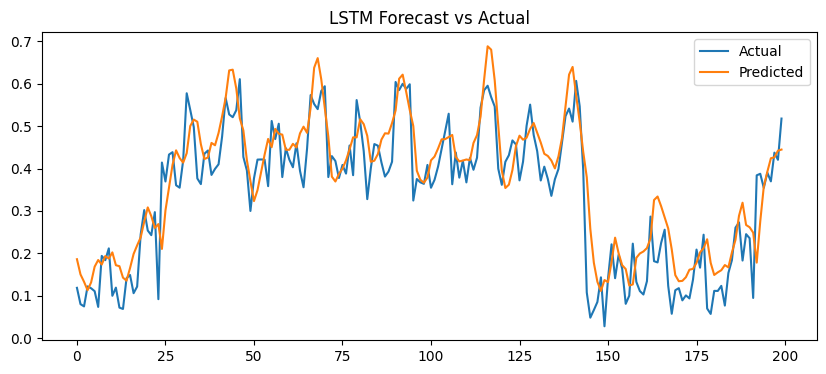

In [15]:
import os
import matplotlib.pyplot as plt

# Ensure results folder exists
os.makedirs('results', exist_ok=True)

plt.figure(figsize=(10,4))
plt.plot(y_test[:200], label='Actual')
plt.plot(pred[:200], label='Predicted')
plt.legend()
plt.title('LSTM Forecast vs Actual')
plt.savefig('results/forecast_visual.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
model.save('../models/trained_model.h5')
np.savetxt('../results/forecast_output.csv',
           np.column_stack((y_test, pred.flatten())),
           delimiter=',', header='Actual,Predicted', comments='')
